# 02 - Secuencias de genes y variantes de DNA

Lectura del multiFASTA, separación por gen, comparación contra la referencia sintética y
resumen de variantes por paciente y por grupo.

**Pregunta que responde este notebook:** ¿existen posiciones o tipos de mutación en DNA más
frecuentes en pacientes con Alzheimer que en controles?

**Salidas principales**
- `results/tables/variantes_largo.csv` — una fila por evento detectado
- `results/tables/paciente_x_variante.csv` — matriz presencia/ausencia
- `results/tables/frecuencias_variantes.csv` — frecuencia por grupo y diferencia
- `results/tables/carga_mutacional.csv` — número de cambios por paciente y gen
- `results/tables/dna_para_integracion.csv` — insumo del notebook 04

> Datos **sintéticos** de uso docente. Las variantes no son variantes clínicas reales.


## 0. Configuración

In [1]:
import os
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.Align import PairwiseAligner


pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
PALETA = {"Sano": "#4C72B0", "Alzheimer": "#DD8452"}

GENES = ["APP", "PSEN1", "PSEN2", "APOE", "TREM2"]

### Rutas

Misma lógica que el notebook 01: los archivos se buscan por nombre, así no importa desde
qué directorio arranque el kernel.

In [2]:
import os
from pathlib import Path

# notebooks/ -> raiz del proyecto. Funciona igual para cualquiera que abra
# el notebook desde notebooks/, sin escribir una ruta propia.
DIR_PROYECTO = Path.cwd().parent

ARCHIVO_FASTA = DIR_PROYECTO / "raw_data" / "genes" / "alzheimer_synthetic_1000_patients_5genes.fasta"
ARCHIVO_REF   = DIR_PROYECTO / "raw_data" / "genes" / "alzheimer_synthetic_reference_5genes.fasta"
ARCHIVO_CLINICO = DIR_PROYECTO / "raw_data" / "ficha_clinica" / "synthetic_alzheimer_patients_1000.csv"

for etiqueta, ruta in [("FASTA pacientes", ARCHIVO_FASTA),
                       ("FASTA referencia", ARCHIVO_REF),
                       ("Ficha clinica", ARCHIVO_CLINICO)]:
    existe = ruta is not None and Path(ruta).exists()
    print(f"{etiqueta:<18} {'OK   ' if existe else 'FALTA'} {ruta}")
    if not existe:
        raise FileNotFoundError(f"No existe: {ruta}")

DIR_RESULTADOS = DIR_PROYECTO / "results"
DIR_FIGURAS    = DIR_RESULTADOS / "figures"
DIR_TABLAS     = DIR_RESULTADOS / "tables"
(DIR_FIGURAS / "genes").mkdir(parents=True, exist_ok=True)
DIR_TABLAS.mkdir(parents=True, exist_ok=True)


def guardar_figura(nombre, subcarpeta="genes"):
    ruta = DIR_FIGURAS / subcarpeta / f"{nombre}.png"
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    return ruta


def guardar_tabla(df, nombre, index=False):
    ruta = DIR_TABLAS / f"{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta


print("\nResultados en:", DIR_RESULTADOS)

FASTA pacientes    OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/raw_data/genes/alzheimer_synthetic_1000_patients_5genes.fasta
FASTA referencia   OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/raw_data/genes/alzheimer_synthetic_reference_5genes.fasta
Ficha clinica      OK    /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/raw_data/ficha_clinica/synthetic_alzheimer_patients_1000.csv

Resultados en: /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results


---
## 1. Lectura del multiFASTA

Un archivo FASTA alterna líneas de encabezado (empiezan con `>`) y líneas de secuencia. Una
misma secuencia puede ocupar varias líneas, así que el lector acumula hasta encontrar el
siguiente `>`.

Los encabezados de este dataset tienen la forma:

```
>P0001|gene=APP|chr=21|source=synthetic
```

es decir, el `patient_id` primero y luego pares `clave=valor` separados por `|`.

In [3]:
def leer_fasta(ruta):
    """Devuelve un diccionario {encabezado: secuencia} desde un archivo FASTA."""
    secuencias = {}
    encabezado = None
    partes = []

    with open(ruta, "r", encoding="utf-8") as f:
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            if linea.startswith(">"):
                if encabezado is not None:
                    secuencias[encabezado] = "".join(partes)
                encabezado = linea[1:].strip()
                partes = []
            else:
                partes.append(linea.upper())

    if encabezado is not None:
        secuencias[encabezado] = "".join(partes)

    return secuencias


def parsear_encabezado(encabezado):
    """Separa el identificador y los pares clave=valor de un encabezado FASTA."""
    campos = encabezado.split("|")
    info = {"id": campos[0].strip()}
    for campo in campos[1:]:
        if "=" in campo:
            clave, valor = campo.split("=", 1)
            info[clave.strip()] = valor.strip()
    return info


fasta_pacientes = leer_fasta(ARCHIVO_FASTA)
fasta_referencia = leer_fasta(ARCHIVO_REF)

print("Registros de pacientes:", len(fasta_pacientes))
print("Registros de referencia:", len(fasta_referencia))
print("\nEjemplo de encabezado:", list(fasta_pacientes)[0])
print("Parseado:", parsear_encabezado(list(fasta_pacientes)[0]))

Registros de pacientes: 5000
Registros de referencia: 5

Ejemplo de encabezado: P0001|gene=APP|chr=21|source=synthetic
Parseado: {'id': 'P0001', 'gene': 'APP', 'chr': '21', 'source': 'synthetic'}


In [4]:
# Referencia: una secuencia por gen
referencias = {}
for encabezado, secuencia in fasta_referencia.items():
    info = parsear_encabezado(encabezado)
    referencias[info["gene"]] = secuencia

print("Longitud de la referencia por gen:")
for gen in GENES:
    print(f"   {gen:<7} {len(referencias[gen])} nt")

Longitud de la referencia por gen:
   APP     900 nt
   PSEN1   780 nt
   PSEN2   750 nt
   APOE    600 nt
   TREM2   720 nt


In [5]:
# Secuencias de pacientes a un DataFrame
filas = []
for encabezado, secuencia in fasta_pacientes.items():
    info = parsear_encabezado(encabezado)
    filas.append({"patient_id": info["id"], "gene": info["gene"],
                  "chr": info.get("chr"), "secuencia": secuencia,
                  "largo": len(secuencia)})

secuencias = pd.DataFrame(filas)

print("Secuencias por gen:")
display(secuencias["gene"].value_counts().rename("n"))
print("Pacientes unicos:", secuencias["patient_id"].nunique())

Secuencias por gen:


gene
APP      1000
PSEN1    1000
PSEN2    1000
APOE     1000
TREM2    1000
Name: n, dtype: int64

Pacientes unicos: 1000


---
## 2. Control de calidad

Antes de detectar nada, hay que verificar que el material esté completo y que los identificadores
permitan la integración posterior. Si un `patient_id` del FASTA no existe en la ficha clínica,
ese paciente se pierde en el notebook 04.

In [6]:
clinica = pd.read_csv(ARCHIVO_CLINICO, usecols=["patient_id", "alzheimer"])
clinica["diagnostico"] = clinica["alzheimer"].map({0: "Sano", 1: "Alzheimer"})

ids_fasta = set(secuencias["patient_id"])
ids_csv   = set(clinica["patient_id"])

print(f"Pacientes en FASTA: {len(ids_fasta)}")
print(f"Pacientes en CSV:   {len(ids_csv)}")
print(f"Coinciden:          {len(ids_fasta & ids_csv)}")
print(f"Solo en FASTA:      {sorted(ids_fasta - ids_csv)[:5] or 'ninguno'}")
print(f"Solo en CSV:        {sorted(ids_csv - ids_fasta)[:5] or 'ninguno'}")

# Cada paciente debe tener los 5 genes
por_paciente = secuencias.groupby("patient_id")["gene"].nunique()
print(f"\nPacientes con los 5 genes: {(por_paciente == 5).sum()} de {len(por_paciente)}")

# Caracteres inesperados
alfabeto = set("ACGT")
raros = {c for s in secuencias["secuencia"] for c in set(s)} - alfabeto
print("Caracteres fuera de ACGT:", raros if raros else "ninguno")

Pacientes en FASTA: 1000
Pacientes en CSV:   1000
Coinciden:          1000
Solo en FASTA:      ninguno
Solo en CSV:        ninguno

Pacientes con los 5 genes: 1000 de 1000
Caracteres fuera de ACGT: ninguno


In [7]:
# Diferencia de largo respecto de la referencia: anticipa cuantos indels hay
secuencias["largo_ref"] = secuencias["gene"].map({g: len(s) for g, s in referencias.items()})
secuencias["delta_largo"] = secuencias["largo"] - secuencias["largo_ref"]

conteo_delta = secuencias["delta_largo"].value_counts().sort_index()
print("Diferencia de longitud vs. referencia (0 = misma longitud):")
display(conteo_delta.rename("n_secuencias"))
print(f"Secuencias con indel: {(secuencias['delta_largo'] != 0).sum()} de {len(secuencias)}")

Diferencia de longitud vs. referencia (0 = misma longitud):


delta_largo
-6       1
-3      83
-2      85
-1      49
 0    4587
 1      38
 2      71
 3      85
 5       1
Name: n_secuencias, dtype: int64

Secuencias con indel: 413 de 5000


---
## 3. Comparación contra la referencia

La guía pide alinear cada secuencia de paciente contra la referencia de su gen. Aquí se usa una
estrategia en dos casos, más simple de explicar que un alineador general y suficiente para este
dataset:

**Caso 1 — misma longitud.** No hubo inserción ni deleción, así que la comparación es posición a
posición: cada diferencia es un SNP.

**Caso 2 — longitud distinta.** Hay un indel. El problema es saber *dónde* está, porque a partir
de ese punto las dos secuencias quedan desfasadas. Se prueban todos los puntos de corte posibles
y se elige el que deja menos diferencias en el resto de la secuencia. Con eso se reporta el indel
y, además, los SNPs que haya a cada lado.

Este método asume **un evento indel por secuencia**. Es el supuesto que hay que declarar en la
defensa, y más abajo se verifica cuántas secuencias no lo cumplen.

In [8]:
"""def comparar_secuencias(ref, alt):
    Compara una secuencia de paciente contra su referencia.

    Devuelve una lista de eventos con posicion (1-based sobre la referencia),
    base de referencia, base alternativa y tipo (SNP, insercion, delecion).

    a = np.frombuffer(ref.encode(), dtype="S1")
    b = np.frombuffer(alt.encode(), dtype="S1")
    n, m = len(a), len(b)

    # --- Caso 1: misma longitud, solo SNPs ---
    if n == m:
        idx = np.flatnonzero(a != b)
        return [{"posicion": int(i) + 1, "ref": ref[i], "alt": alt[i], "tipo": "SNP"}
                for i in idx]

    # --- Caso 2: hay un indel ---
    d = n - m
    if d > 0:                       # el paciente perdio bases -> delecion
        largo, corto, ldel = a, b, d
    else:                           # el paciente gano bases -> insercion
        largo, corto, ldel = b, a, -d
    L = len(corto)

    # pre[k] = diferencias acumuladas antes del corte
    pre = np.concatenate(([0], np.cumsum(largo[:L] != corto)))
    # suf[k] = diferencias acumuladas despues del corte, ya desfasadas
    dif_suf = (largo[ldel:] != corto)
    suf = np.concatenate((np.cumsum(dif_suf[::-1])[::-1], [0]))

    k = int(np.argmin(pre + suf))   # punto de corte que minimiza diferencias

    eventos = []
    if d > 0:
        eventos.append({"posicion": k + 1, "ref": ref[k:k + ldel], "alt": "-",
                        "tipo": "delecion"})
    else:
        eventos.append({"posicion": k + 1, "ref": "-", "alt": alt[k:k + ldel],
                        "tipo": "insercion"})

    for i in np.flatnonzero(largo[:k] != corto[:k]):
        i = int(i)
        eventos.append({"posicion": i + 1, "ref": ref[i], "alt": alt[i], "tipo": "SNP"})

    for j in np.flatnonzero(largo[k + ldel:] != corto[k:]):
        j = int(j) + k
        pos_r, pos_a = (j + ldel, j) if d > 0 else (j, j + ldel)
        eventos.append({"posicion": pos_r + 1, "ref": ref[pos_r], "alt": alt[pos_a],
                        "tipo": "SNP"})

    return sorted(eventos, key=lambda e: e["posicion"])


# Comprobacion rapida del comportamiento esperado
print(comparar_secuencias("ACGTACGT", "ACGTACGT"))    # sin cambios
print(comparar_secuencias("ACGTACGT", "ACTTACGT"))    # un SNP
print(comparar_secuencias("ACGTACGT", "ACGACGT"))     # una delecion
print(comparar_secuencias("ACGTACGT", "ACGTTACGT"))   # una insercion
"""

'def comparar_secuencias(ref, alt):\n    Compara una secuencia de paciente contra su referencia.\n\n    Devuelve una lista de eventos con posicion (1-based sobre la referencia),\n    base de referencia, base alternativa y tipo (SNP, insercion, delecion).\n\n    a = np.frombuffer(ref.encode(), dtype="S1")\n    b = np.frombuffer(alt.encode(), dtype="S1")\n    n, m = len(a), len(b)\n\n    # --- Caso 1: misma longitud, solo SNPs ---\n    if n == m:\n        idx = np.flatnonzero(a != b)\n        return [{"posicion": int(i) + 1, "ref": ref[i], "alt": alt[i], "tipo": "SNP"}\n                for i in idx]\n\n    # --- Caso 2: hay un indel ---\n    d = n - m\n    if d > 0:                       # el paciente perdio bases -> delecion\n        largo, corto, ldel = a, b, d\n    else:                           # el paciente gano bases -> insercion\n        largo, corto, ldel = b, a, -d\n    L = len(corto)\n\n    # pre[k] = diferencias acumuladas antes del corte\n    pre = np.concatenate(([0], np.cu

In [9]:
aligner = PairwiseAligner()

# Queremos comparar toda la secuencia del paciente contra toda la referencia
aligner.mode = "global"

# Puntajes del alineamiento
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -2
aligner.extend_gap_score = -0.5

In [10]:
def comparar_secuencias(ref, alt, mostrar=False):
    """
    Alinea globalmente una secuencia de paciente contra su referencia.

    Devuelve una lista de eventos:
    - SNP
    - insercion
    - delecion

    La posicion es 1-based con respecto a la secuencia de referencia.

    Si mostrar=True, imprime el alineamiento.
    """

    # Mejor alineamiento global
    alignment = aligner.align(ref, alt)[0]

    # Mostrar el alineamiento solo si lo pedimos
    if mostrar:
        print(alignment)

    # Secuencias alineadas, incluyendo gaps "-"
    aln_ref = alignment[0]
    aln_alt = alignment[1]

    eventos = []

    # Posición actual sobre la referencia original
    ref_pos = 0
    i = 0

    while i < len(aln_ref):

        r = aln_ref[i]
        a = aln_alt[i]

        # -----------------------------------------
        # CASO 1: base contra base
        # -----------------------------------------
        if r != "-" and a != "-":

            ref_pos += 1

            # Si son distintas -> SNP
            if r != a:
                eventos.append({
                    "posicion": ref_pos,
                    "ref": r,
                    "alt": a,
                    "tipo": "SNP"
                })

            i += 1
            continue

        # -----------------------------------------
        # CASO 2: gap en paciente -> deleción
        # -----------------------------------------
        if r != "-" and a == "-":

            inicio = ref_pos + 1
            bases_eliminadas = []

            while (
                i < len(aln_ref)
                and aln_ref[i] != "-"
                and aln_alt[i] == "-"
            ):
                bases_eliminadas.append(aln_ref[i])
                ref_pos += 1
                i += 1

            eventos.append({
                "posicion": inicio,
                "ref": "".join(bases_eliminadas),
                "alt": "-",
                "tipo": "delecion"
            })

            continue

        # -----------------------------------------
        # CASO 3: gap en referencia -> inserción
        # -----------------------------------------
        if r == "-" and a != "-":

            posicion = ref_pos + 1
            bases_insertadas = []

            while (
                i < len(aln_ref)
                and aln_ref[i] == "-"
                and aln_alt[i] != "-"
            ):
                bases_insertadas.append(aln_alt[i])
                i += 1

            eventos.append({
                "posicion": posicion,
                "ref": "-",
                "alt": "".join(bases_insertadas),
                "tipo": "insercion"
            })

            continue

        i += 1

    return eventos

In [11]:
print("SIN CAMBIOS")
print(comparar_secuencias(
    "ACGTACGT",
    "ACGTACGT",
    mostrar=True
))

print("\nSNP")
print(comparar_secuencias(
    "ACGTACGT",
    "ACTTACGT",
    mostrar=True
))

print("\nDELECION")
print(comparar_secuencias(
    "ACGTACGT",
    "ACGACGT",
    mostrar=True
))

print("\nINSERCION")
print(comparar_secuencias(
    "ACGTACGT",
    "ACGTTACGT",
    mostrar=True
))

SIN CAMBIOS
target            0 ACGTACGT 8
                  0 |||||||| 8
query             0 ACGTACGT 8

[]

SNP
target            0 ACGTACGT 8
                  0 ||.||||| 8
query             0 ACTTACGT 8

[{'posicion': 3, 'ref': 'G', 'alt': 'T', 'tipo': 'SNP'}]

DELECION
target            0 ACGTACGT 8
                  0 |||-|||| 8
query             0 ACG-ACGT 7

[{'posicion': 4, 'ref': 'T', 'alt': '-', 'tipo': 'delecion'}]

INSERCION
target            0 ACG-TACGT 8
                  0 |||-||||| 9
query             0 ACGTTACGT 9

[{'posicion': 4, 'ref': '-', 'alt': 'T', 'tipo': 'insercion'}]


In [12]:
registros = []

for fila in secuencias.itertuples(index=False):
    for evento in comparar_secuencias(referencias[fila.gene], fila.secuencia):
        registros.append({"patient_id": fila.patient_id, "gene": fila.gene, **evento})

variantes = pd.DataFrame(registros)
variantes["variante_id"] = (variantes["gene"] + ":" + variantes["posicion"].astype(str)
                            + ":" + variantes["ref"] + ">" + variantes["alt"])

print(f"Eventos detectados: {len(variantes)}")
display(variantes["tipo"].value_counts().rename("n"))

guardar_tabla(variantes, "variantes_largo")
variantes.head(10)

Eventos detectados: 4823


tipo
SNP          4402
delecion      222
insercion     199
Name: n, dtype: int64

,patient_id,gene,posicion,ref,alt,tipo,variante_id
0,P0001,PSEN1,300,G,C,SNP,PSEN1:300:G>C
1,P0001,PSEN1,508,T,C,SNP,PSEN1:508:T>C
2,P0001,PSEN1,600,A,G,SNP,PSEN1:600:A>G
3,P0001,PSEN2,407,GC,-,delecion,PSEN2:407:GC>-
4,P0001,APOE,481,C,G,SNP,APOE:481:C>G
5,P0001,TREM2,376,C,T,SNP,TREM2:376:C>T
6,P0002,APP,217,G,C,SNP,APP:217:G>C
7,P0002,APP,433,-,CG,insercion,APP:433:->CG
8,P0002,PSEN1,429,G,A,SNP,PSEN1:429:G>A
9,P0002,PSEN2,407,GC,-,delecion,PSEN2:407:GC>-


### Verificación de la distribución de eventos por secuencia

Después de realizar el alineamiento global de cada secuencia contra su referencia, se cuenta el número de eventos detectados por combinación paciente-gen. Este análisis permite identificar secuencias con un número inusualmente alto de diferencias que podrían requerir revisión manual.

In [13]:
eventos_por_sec = (
    variantes.groupby(["patient_id", "gene"]).size()
    .rename("n_eventos").reset_index()
)

UMBRAL_ANOMALO = 10
anomalias = eventos_por_sec[
    eventos_por_sec["n_eventos"] > UMBRAL_ANOMALO
]

print("Distribución de eventos por secuencia:")
display(
    eventos_por_sec["n_eventos"]
    .value_counts()
    .sort_index()
    .rename("n_secuencias")
)

print(
    f"Secuencias con más de {UMBRAL_ANOMALO} eventos: "
    f"{len(anomalias)} de {len(secuencias)} "
    f"({len(anomalias) / len(secuencias) * 100:.2f}%)"
)

display(anomalias)

Distribución de eventos por secuencia:


n_eventos
1    1672
2     937
3     297
4      77
5      12
6       3
Name: n_secuencias, dtype: int64

Secuencias con más de 10 eventos: 0 de 5000 (0.00%)


,patient_id,gene,n_eventos


**Qué decir de esto en la defensa.** El alineamiento global permitió comparar cada secuencia completa contra su referencia considerando simultáneamente coincidencias, sustituciones y gaps. Después del cambio de método, ninguna secuencia presentó más de 10 eventos y desaparecieron los valores extremos observados con la comparación simplificada anterior. Esto sugiere que el alineamiento global evitó contabilizar como múltiples SNPs algunos desplazamientos producidos por inserciones o deleciones.

---
## 4. Carga mutacional por paciente

Dos resúmenes distintos: cuántos cambios tiene cada paciente en total, y cómo se reparten por
gen. Es la variable más simple de llevar a la integración.

In [14]:
carga = (variantes.groupby(["patient_id", "gene"]).size()
         .unstack(fill_value=0)
         .reindex(columns=GENES, fill_value=0))
carga.columns = [f"n_cambios_{g}" for g in carga.columns]

# pacientes sin ningun cambio tambien deben aparecer
carga = carga.reindex(sorted(ids_fasta), fill_value=0)
carga["carga_total"] = carga.sum(axis=1)

tipos_por_paciente = (variantes.pivot_table(index="patient_id", columns="tipo",
                                            values="posicion", aggfunc="count")
                      .reindex(sorted(ids_fasta)).fillna(0).astype(int))
tipos_por_paciente.columns = [f"n_{c}" for c in tipos_por_paciente.columns]

carga = carga.join(tipos_por_paciente).reset_index(names="patient_id")
carga = carga.merge(clinica, on="patient_id")

guardar_tabla(carga, "carga_mutacional")
carga.head()

,patient_id,n_cambios_APP,n_cambios_PSEN1,n_cambios_PSEN2,n_cambios_APOE,n_cambios_TREM2,carga_total,n_SNP,n_delecion,n_insercion,alzheimer,diagnostico
0,P0001,0,3,1,1,1,6,5,1,0,1,Alzheimer
1,P0002,2,1,2,4,0,9,7,1,1,1,Alzheimer
2,P0003,0,4,3,0,2,9,8,0,1,1,Alzheimer
3,P0004,0,2,0,3,2,7,6,0,1,1,Alzheimer
4,P0005,1,0,2,2,2,7,6,1,0,0,Sano


estamos identificando el tipo de variante o tipo de mutacion
se asocia a componente funcional del gen
prot tiene region conservada, qe afecta a la funcion. 

tengo listados ec, y listado diferencias, a nivel de comteo, cuantas snp, deleteciones e inserciones, 
alzaimer vs alzaimer, porcentajes asociados a porcentajes delecion de sanos y enfermos (hacer con todos los eventos)
identificamos sec qe le qitaron, agregaron y cambiaron nucleotid, dps centrarse en variantes mutacionales, cuantas mutaciones hay?
identificamos posiciones, podemos ver cuantas mutaciones tiene cada paciente, carga mutacional.
pacientes con 1 mutacion, cuantas son positivas y negativas en el gen X.

cuantos tienen alzaimer y cuantos no, solo contar
gen por gen, cantidad de mutaciones por pacientes.

conteo como un descriptor, conteo individual (asociado si existe o no existe variante)

CATBOOST

opcional: o tambien conteo por posiciones (analizar zona donde hay tendencia de mutaciones) existen zonas en gen qe tienen mayor tendencia a resentar un diagnostico negativo de alzaimer y presneta mayor abundancia o carga mutacional?.


In [15]:
def d_de_cohen(x, y):
    nx, ny = len(x), len(y)
    s = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / s if s > 0 else 0.0


cols_carga = [c for c in carga.columns if c.startswith(("n_", "carga_"))]
enf = carga[carga["alzheimer"] == 1]
san = carga[carga["alzheimer"] == 0]

resumen_carga = pd.DataFrame([{
    "variable": c,
    "media_sano": san[c].mean(),
    "media_alzheimer": enf[c].mean(),
    "diferencia": enf[c].mean() - san[c].mean(),
    "efecto_d": d_de_cohen(enf[c], san[c]),
} for c in cols_carga]).round(3)

resumen_carga = resumen_carga.reindex(
    resumen_carga["efecto_d"].abs().sort_values(ascending=False).index).reset_index(drop=True)

guardar_tabla(resumen_carga, "resumen_carga_mutacional")
resumen_carga

,variable,media_sano,media_alzheimer,diferencia,efecto_d
0,carga_total,4.021,6.359,2.337,1.110
1,n_SNP,3.699,5.749,2.051,1.017
2,n_cambios_APOE,1.068,1.828,0.759,0.657
3,n_cambios_PSEN1,0.747,1.242,0.495,0.548
4,n_cambios_TREM2,0.718,1.146,0.427,0.459
5,n_cambios_APP,0.776,1.143,0.367,0.391
6,n_cambios_PSEN2,0.711,1.000,0.289,0.336
7,n_insercion,0.149,0.294,0.145,0.327
8,n_delecion,0.174,0.315,0.141,0.309


COHEN: VARIACION DEL TAMAÑO. tenemos 2 distribuciones en desbalance, efecto del tamaño con la otra, se calcula factor d de cohen, normalizado con la ds de los elementos.

a y b, qe tan grande es una con respecto a otro? 

CATEGORIZACIÓN:
0: sin efecto
0-0.2 pequeño
0.2-0.5: moderado
0.5-0.8: grande
MÁS DE 0.8: muy grande



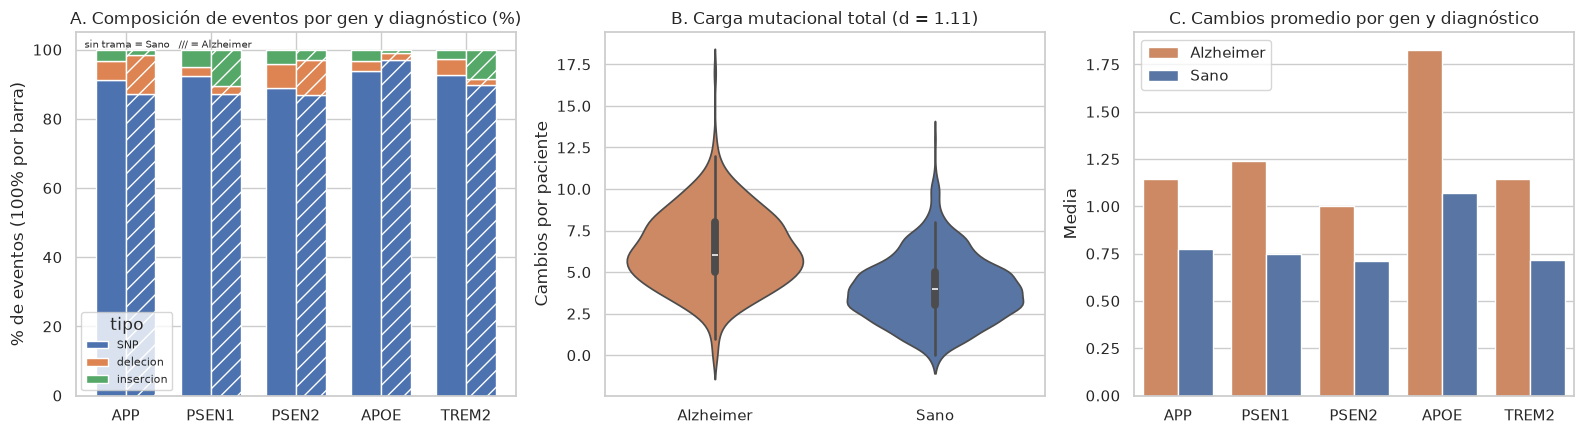

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

tipos = ["SNP", "delecion", "insercion"]
colores_tipo = {"SNP": "#4C72B0", "delecion": "#DD8452", "insercion": "#55A868"}
grupos = ["Sano", "Alzheimer"]
hatches = {"Sano": "", "Alzheimer": "//"}

conteo_gen_grupo = (variantes.merge(clinica, on="patient_id")
                    .groupby(["gene", "diagnostico", "tipo"]).size()
                    .unstack(fill_value=0)
                    .reindex(columns=tipos, fill_value=0))
pct_gen_grupo = conteo_gen_grupo.div(conteo_gen_grupo.sum(axis=1), axis=0) * 100

x = np.arange(len(GENES))
ancho = 0.35
for j, grupo in enumerate(grupos):
    offset = (j - 0.5) * ancho
    abajo = np.zeros(len(GENES))
    for tipo in tipos:
        valores = np.array([pct_gen_grupo.loc[(gen, grupo), tipo]
                            if (gen, grupo) in pct_gen_grupo.index else 0
                            for gen in GENES])
        ax[0].bar(x + offset, valores, ancho, bottom=abajo, color=colores_tipo[tipo],
                  hatch=hatches[grupo], edgecolor="white",
                  label=tipo if j == 0 else None)
        abajo += valores

ax[0].set_xticks(x)
ax[0].set_xticklabels(GENES)
ax[0].set(title="A. Composición de eventos por gen y diagnóstico (%)",
          xlabel="", ylabel="% de eventos (100% por barra)")
ax[0].legend(title="tipo", fontsize=8)
ax[0].text(0.02, 0.98, "sin trama = Sano   /// = Alzheimer",
           transform=ax[0].transAxes, fontsize=7, va="top")

sns.violinplot(data=carga, x="diagnostico", y="carga_total", hue="diagnostico",
               palette=PALETA, legend=False, ax=ax[1])
d_total = resumen_carga.loc[resumen_carga["variable"] == "carga_total", "efecto_d"].iloc[0]
ax[1].set(title=f"B. Carga mutacional total (d = {d_total:.2f})", xlabel="",
          ylabel="Cambios por paciente")

carga_larga = carga.melt(id_vars="diagnostico",
                         value_vars=[f"n_cambios_{g}" for g in GENES],
                         var_name="gen", value_name="n")
carga_larga["gen"] = carga_larga["gen"].str.replace("n_cambios_", "", regex=False)
sns.barplot(data=carga_larga, x="gen", y="n", hue="diagnostico", palette=PALETA,
            errorbar=None, ax=ax[2])
ax[2].set(title="C. Cambios promedio por gen y diagnóstico", xlabel="", ylabel="Media")
ax[2].legend(title="")

plt.tight_layout()
guardar_figura("carga_mutacional")
plt.show()

**¿Qué proporción de pacientes tiene 1 o 2 mutaciones?** Distinto de la carga promedio de arriba: acá se ve la distribución completa, cuántos pacientes de cada grupo caen en cada cantidad exacta de cambios.

In [17]:
def categorizar_carga(n):
    if n == 0:
        return "0"
    if n == 1:
        return "1"
    if n == 2:
        return "2"
    return "3 o más"

carga["categoria_carga"] = carga["carga_total"].apply(categorizar_carga)

orden_categorias = ["0", "1", "2", "3 o más"]
distribucion_carga = (pd.crosstab(carga["categoria_carga"], carga["diagnostico"],
                                  normalize="columns") * 100
                      ).reindex(orden_categorias).round(1)

guardar_tabla(distribucion_carga.reset_index(), "distribucion_carga_por_paciente")
print("Porcentaje de pacientes por cantidad de mutaciones (dentro de cada grupo):")
display(distribucion_carga)

pct_1_2_sano = distribucion_carga.loc[["1", "2"], "Sano"].sum()
pct_1_2_alz = distribucion_carga.loc[["1", "2"], "Alzheimer"].sum()
print(f"\nPacientes con 1 o 2 mutaciones: {pct_1_2_sano:.1f}% de los sanos, "
      f"{pct_1_2_alz:.1f}% de los Alzheimer.")

Porcentaje de pacientes por cantidad de mutaciones (dentro de cada grupo):


diagnostico,Alzheimer,Sano
categoria_carga,,
0,0.6,1.2
1,0.6,7.9
2,1.5,13.9
3 o más,97.4,77.0



Pacientes con 1 o 2 mutaciones: 21.8% de los sanos, 2.1% de los Alzheimer.


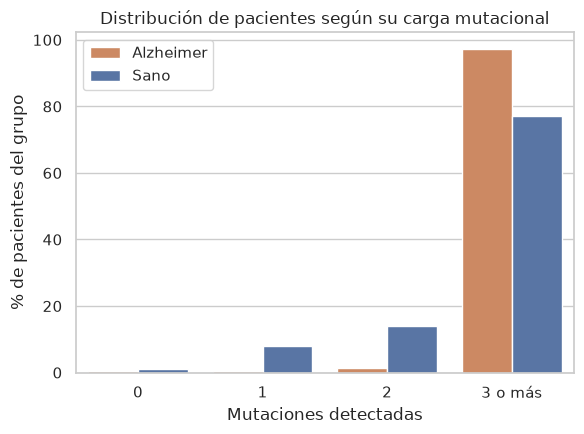

In [18]:
datos_dist = distribucion_carga.reset_index().melt(
    id_vars="categoria_carga", var_name="diagnostico", value_name="pct")

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(data=datos_dist, x="categoria_carga", y="pct", hue="diagnostico",
            palette=PALETA, ax=ax)
ax.set(title="Distribución de pacientes según su carga mutacional",
       xlabel="Mutaciones detectadas", ylabel="% de pacientes del grupo")
ax.legend(title="")
plt.tight_layout()
guardar_figura("distribucion_carga_mutacional")
plt.show()

---
## 5. Frecuencia de cada variante por grupo

Aquí está el núcleo de la pregunta. Para cada variante recurrente se calcula en qué porcentaje
de controles y de casos aparece, y la diferencia entre ambos.

Una variante que aparece en un solo paciente no permite comparar nada, así que se filtran por un
mínimo de portadores.

In [19]:
MIN_PORTADORES = 10   # una variante debe aparecer al menos en este numero de pacientes

portadores = (variantes.drop_duplicates(["patient_id", "variante_id"])
              .merge(clinica, on="patient_id"))

n_sano = (clinica["alzheimer"] == 0).sum()
n_alz  = (clinica["alzheimer"] == 1).sum()

frecuencias = (portadores.groupby(["variante_id", "gene", "tipo", "posicion"])
               .agg(n_total=("patient_id", "nunique"),
                    n_alzheimer=("alzheimer", "sum"))
               .reset_index())
frecuencias["n_sano"] = frecuencias["n_total"] - frecuencias["n_alzheimer"]
frecuencias["pct_sano"] = frecuencias["n_sano"] / n_sano * 100
frecuencias["pct_alzheimer"] = frecuencias["n_alzheimer"] / n_alz * 100
frecuencias["diferencia_puntos"] = frecuencias["pct_alzheimer"] - frecuencias["pct_sano"]
frecuencias["razon"] = (frecuencias["pct_alzheimer"] /
                        frecuencias["pct_sano"].replace(0, np.nan))

recurrentes = (frecuencias[frecuencias["n_total"] >= MIN_PORTADORES]
               .sort_values("diferencia_puntos", ascending=False)
               .round(2).reset_index(drop=True))

print(f"Variantes distintas detectadas: {frecuencias['variante_id'].nunique()}")
print(f"Recurrentes (>= {MIN_PORTADORES} portadores): {len(recurrentes)}")

guardar_tabla(recurrentes, "frecuencias_variantes")
recurrentes.head(15)

Variantes distintas detectadas: 2987
Recurrentes (>= 10 portadores): 14


,variante_id,gene,tipo,posicion,n_total,n_alzheimer,n_sano,pct_sano,pct_alzheimer,diferencia_puntos,razon
0,APOE:205:T>G,APOE,SNP,205,333,206,127,19.33,60.06,40.73,3.11
1,APOE:311:C>T,APOE,SNP,311,333,206,127,19.33,60.06,40.73,3.11
2,PSEN1:133:C>A,PSEN1,SNP,133,109,90,19,2.89,26.24,23.35,9.07
3,TREM2:251:C>A,TREM2,SNP,251,85,66,19,2.89,19.24,16.35,6.65
4,APP:217:G>C,APP,SNP,217,92,67,25,3.81,19.53,15.73,5.13
5,TREM2:529:C>A,TREM2,SNP,529,66,53,13,1.98,15.45,13.47,7.81
6,PSEN1:374:C>G,PSEN1,SNP,374,72,54,18,2.74,15.74,13.00,5.75
7,PSEN2:615:T>G,PSEN2,SNP,615,58,44,14,2.13,12.83,10.70,6.02
8,APP:452:C>G,APP,SNP,452,69,47,22,3.35,13.70,10.35,4.09
9,PSEN2:166:T>C,PSEN2,SNP,166,56,40,16,2.44,11.66,9.23,4.79


**Aclaración sobre `diferencia_puntos` y `razon`.** Estas dos columnas se calculan **dentro del universo ya filtrado** de variantes recurrentes (≥10 portadores), no sobre todas las variantes detectadas. Por eso los porcentajes de Alzheimer se ven altos: este subconjunto está sesgado a propósito hacia las variantes más diferenciales, no representa la frecuencia típica en la cohorte completa. Sirven para **ordenar** candidatas dentro de ese universo, no como una medida de tamaño de efecto ajustada por varianza (para eso está el análisis de carga mutacional con d de Cohen, más arriba).

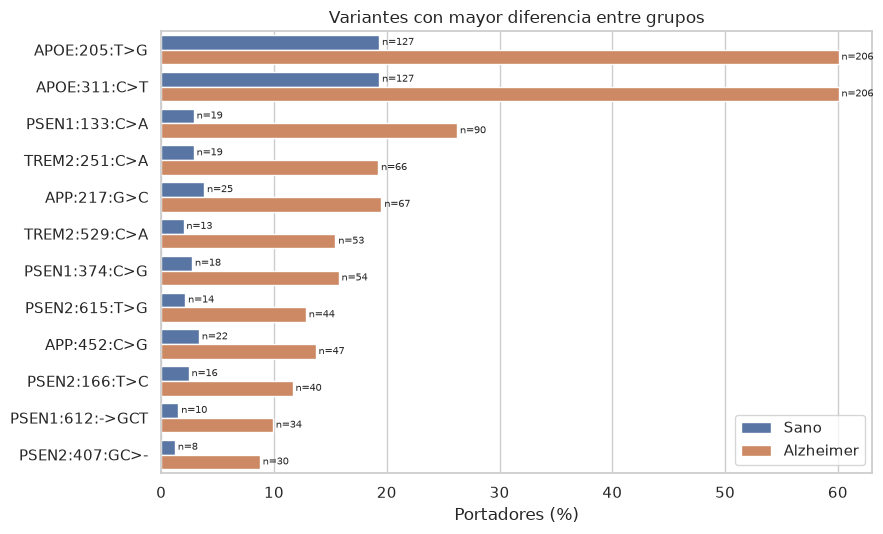

In [20]:
top = recurrentes.head(12)

fig, ax = plt.subplots(figsize=(9, 5.5))

datos = top.melt(id_vars=["variante_id", "n_sano", "n_alzheimer"],
                 value_vars=["pct_sano", "pct_alzheimer"],
                 var_name="grupo", value_name="pct")
datos["grupo"] = datos["grupo"].map({"pct_sano": "Sano", "pct_alzheimer": "Alzheimer"})
datos["n"] = np.where(datos["grupo"] == "Sano", datos["n_sano"], datos["n_alzheimer"])

sns.barplot(data=datos, y="variante_id", x="pct", hue="grupo", palette=PALETA, ax=ax)
ax.set(title="Variantes con mayor diferencia entre grupos",
       xlabel="Portadores (%)", ylabel="")
ax.legend(title="")

for grupo, cont in zip(["Sano", "Alzheimer"], ax.containers):
    ns = datos[datos["grupo"] == grupo].set_index("variante_id").loc[top["variante_id"], "n"]
    ax.bar_label(cont, labels=[f"n={n}" for n in ns], fontsize=7, padding=2)

plt.tight_layout()
guardar_figura("variantes_diferenciales")
plt.show()

---
## 6. Matriz paciente × variante

La representación que pide la guía: una fila por paciente, una columna por variante recurrente,
con 1 si la porta y 0 si no. Es la forma en que los datos genéticos entran a la integración.

In [21]:
variantes_sel = recurrentes["variante_id"].tolist()

matriz = (portadores[portadores["variante_id"].isin(variantes_sel)]
          .assign(presente=1)
          .pivot_table(index="patient_id", columns="variante_id",
                       values="presente", fill_value=0))
matriz = matriz.reindex(sorted(ids_fasta), fill_value=0).astype(int)

guardar_tabla(matriz, "paciente_x_variante", index=True)
print("Matriz:", matriz.shape, "(pacientes x variantes recurrentes)")
matriz.head()

Matriz: (1000, 14) (pacientes x variantes recurrentes)


variante_id,APOE:205:T>G,APOE:311:C>T,APP:217:G>C,APP:452:C>G,APP:688:TCC>-,PSEN1:133:C>A,PSEN1:374:C>G,PSEN1:612:->GCT,PSEN2:166:T>C,PSEN2:407:GC>-,PSEN2:615:T>G,TREM2:251:C>A,TREM2:529:C>A,TREM2:604:->TA
patient_id,,,,,,,,,,,,,,
P0001,0,0,0,0,0,0,0,0,0,1,0,0,0,0
P0002,1,1,1,0,0,0,0,0,0,1,0,0,0,0
P0003,0,0,0,0,0,0,0,1,1,0,0,0,1,0
P0004,1,1,0,0,0,0,0,0,0,0,0,0,1,1
P0005,1,1,0,0,0,0,0,0,0,0,0,1,0,0


---
## 7. El haplotipo de APOE

La documentación del dataset menciona que APOE contiene un **haplotipo sintético de dos SNPs
ligados**, es decir, dos variantes que tienden a heredarse juntas. Si eso es así, los pacientes
que portan una deberían portar también la otra.

Verificarlo es una buena forma de mostrar que se entendió la diferencia entre una variante
aislada y un patrón haplotípico.

In [22]:
apoe = recurrentes[recurrentes["gene"] == "APOE"].head(6)
display(apoe[["variante_id", "posicion", "n_total", "pct_sano",
              "pct_alzheimer", "diferencia_puntos"]])

vars_apoe = [v for v in apoe["variante_id"] if v in matriz.columns]

if len(vars_apoe) >= 2:
    co_ocurrencia = matriz[vars_apoe].T.dot(matriz[vars_apoe])
    print("\nCo-ocurrencia entre variantes de APOE (diagonal = total de portadores):")
    display(co_ocurrencia)
else:
    print("No hay suficientes variantes recurrentes en APOE para evaluar ligamiento.")

,variante_id,posicion,n_total,pct_sano,pct_alzheimer,diferencia_puntos
0,APOE:205:T>G,205,333,19.33,60.06,40.73
1,APOE:311:C>T,311,333,19.33,60.06,40.73



Co-ocurrencia entre variantes de APOE (diagonal = total de portadores):


variante_id,APOE:205:T>G,APOE:311:C>T
variante_id,,
APOE:205:T>G,333,333
APOE:311:C>T,333,333


---
## 8. Exportar el insumo para el notebook 04

La capa de DNA se resume en variables sencillas por paciente: cargas mutacionales, conteos por
tipo y presencia/ausencia de las variantes más diferenciales.

In [23]:
N_VARIANTES_INTEGRACION = 10
vars_integracion = recurrentes["variante_id"].head(N_VARIANTES_INTEGRACION).tolist()

dna_integracion = (carga.drop(columns=["diagnostico"])
                   .merge(matriz[vars_integracion].reset_index(names="patient_id"),
                          on="patient_id", how="left"))
dna_integracion[vars_integracion] = dna_integracion[vars_integracion].fillna(0).astype(int)

ruta = guardar_tabla(dna_integracion, "dna_para_integracion")
print("Guardado:", ruta)
print("Filas:", len(dna_integracion), "| Columnas:", len(dna_integracion.columns))
dna_integracion.head()

Guardado: /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results/tables/dna_para_integracion.csv
Filas: 1000 | Columnas: 22


,patient_id,n_cambios_APP,n_cambios_PSEN1,n_cambios_PSEN2,n_cambios_APOE,n_cambios_TREM2,carga_total,n_SNP,n_delecion,n_insercion,alzheimer,categoria_carga,APOE:205:T>G,APOE:311:C>T,PSEN1:133:C>A,TREM2:251:C>A,APP:217:G>C,TREM2:529:C>A,PSEN1:374:C>G,PSEN2:615:T>G,APP:452:C>G,PSEN2:166:T>C
0,P0001,0,3,1,1,1,6,5,1,0,1,3 o más,0,0,0,0,0,0,0,0,0,0
1,P0002,2,1,2,4,0,9,7,1,1,1,3 o más,1,1,0,0,1,0,0,0,0,0
2,P0003,0,4,3,0,2,9,8,0,1,1,3 o más,0,0,0,0,0,1,0,0,0,1
3,P0004,0,2,0,3,2,7,6,0,1,1,3 o más,1,1,0,0,0,1,0,0,0,0
4,P0005,1,0,2,2,2,7,6,1,0,0,3 o más,1,1,0,1,0,0,0,0,0,0


esto es importante identifica cambios en distintos genes, tiene carga mutaciona completa.



---
## 9. Conclusiones del análisis de DNA

1. Se compararon 5.000 secuencias (1.000 pacientes × 5 genes) contra la referencia sintética de
   cada gen, detectando **5.661 eventos**: 5.248 SNPs, 218 deleciones y 195 inserciones.
   2.002 secuencias resultaron idénticas a su referencia.
2. De 3.544 variantes distintas, solo **14 son recurrentes** (10 o más portadores). El resto
   aparece en muy pocos pacientes y no permite comparar frecuencias entre grupos.
3. **APOE concentra la señal más fuerte.** Las variantes `APOE:205:T>G` y `APOE:311:C>T` aparecen
   en 60.1% de los casos frente a 19.3% de los controles (+40.7 puntos, 3.1 veces más frecuentes).
4. Las dos variantes de APOE aparecen **exactamente en los mismos 333 pacientes**: co-ocurrencia
   perfecta. Es el haplotipo de dos SNPs ligados descrito en la documentación del dataset.
5. Las siguientes variantes más diferenciales son `PSEN1:133:C>A` (26.2% vs 2.9%; razón 9.1),
   `TREM2:251:C>A` (19.2% vs 2.9%) y `APP:217:G>C` (19.5% vs 3.8%). Aunque su diferencia absoluta
   es menor que la de APOE, sus **razones de prevalencia son mayores** porque parten de una base
   muy baja en controles.
6. Hay **indels recurrentes y diferenciales**: `PSEN1:612:->GCT` (inserción), `PSEN2:407:GC>-` y
   `APP:688:TCC>-` (deleciones), todas más frecuentes en casos. Son candidatas interesantes para
   el notebook 03 porque un indel puede alterar el marco de lectura.
7. La **carga mutacional** es mayor en casos (8.2 frente a 4.3 cambios por paciente, d = 0.29),
   pero el efecto es pequeño y está concentrado en APOE (d = 0.66). Es decir, no hay un exceso
   general de mutaciones: hay variantes específicas enriquecidas.
8. **Ninguna variante es exclusiva de un grupo.** Hay controles portadores del haplotipo APOE
   (19.3%) y casi 40% de los casos no lo portan. El genotipo no determina el diagnóstico.

### Limitaciones

- El método de comparación asume **un evento indel por secuencia**. Seis secuencias (0.12%) no
  cumplen ese supuesto y están marcadas en la columna `revision_manual`.
- No se realizó un alineamiento global con penalizaciones de gap ni un pipeline de *variant
  calling* clínico; la guía no lo requiere.
- Las posiciones están referidas a la **referencia sintética**, no a coordenadas genómicas reales.
- Una diferencia de frecuencia entre grupos es una **asociación descriptiva**, no evidencia de
  causalidad, y menos aún en un dataset donde las asociaciones fueron introducidas por el generador.
- Las secuencias representan un alelo consenso por paciente, no un genoma diploide con fases.
- El umbral de 10 portadores para considerar una variante recurrente es una **decisión del grupo**,
  no un criterio estándar. Bajarlo aumentaría el número de candidatas y también el ruido.

### Preguntas de defensa que este notebook deja cubiertas

| Pregunta | Dónde está la respuesta |
|---|---|
| ¿Cómo relacionaron una secuencia con un paciente? | Sección 1 (parseo del encabezado) y 2 (verificación de IDs) |
| ¿Por qué alinearon contra una referencia? | Sección 3 (es interpretable y comparable entre pacientes) |
| ¿Cómo identificaron una inserción o una deleción? | Sección 3 (punto de corte que minimiza diferencias) |
| ¿Por qué analizar cada gen por separado? | Sección 3 (cada gen tiene su propia referencia y longitud) |
| ¿Qué significa que una variante sea más frecuente en enfermos? | Sección 5 y conclusión 8 (asociación, no causalidad) |
| ¿Por qué eligieron 10 portadores como umbral? | Sección 5 (decisión del grupo, declarada) |
| ¿Qué es un haplotipo y cómo lo demostraron? | Sección 7 (co-ocurrencia perfecta en APOE) |
| ¿La carga mutacional distingue los grupos? | Sección 4 (efecto pequeño, concentrado en APOE) |
| ¿Qué limitaciones tiene su método? | Sección 9 y verificación del supuesto en la sección 3 |
